In [1]:
pip install cartopy


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Belgium mask with Belgian-flag colors + Copernicus download rectangle
# (labels placed INSIDE the rectangle)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
import matplotlib.path as mpath
import cartopy.crs as ccrs
from cartopy.io import shapereader
from cartopy.mpl.path import shapely_to_path

# ── Config ────────────────────────────────────────────────────────────────
MASK_PATH = "/Users/coralieroland/ACI-Python/data/required_data/mask_BEL.nc"  # or your overlap file
OUT_PNG   = "BEL_mask_flag_rect.png"
OUT_PDF   = "BEL_mask_flag_rect.pdf"
PAD_DEG   = 0.10  # padding around extent

# Copernicus download rectangle (degrees)
NORTH = 51.35
SOUTH = 49.30
WEST  = 2.35   # “W 2.35°” as requested (label text uses W)
EAST  = 6.21   # “E 6.21°”

# ── Load mask & normalize coordinates ─────────────────────────────────────
ds = xr.open_dataset(MASK_PATH)
if "mask" in ds: var_name = "mask"
elif "mask_frac" in ds: var_name = "mask_frac"
else: raise KeyError("Neither 'mask' nor 'mask_frac' found in the mask file.")
da = ds[var_name]

rename_map = {}
if "lon" in da.coords and "longitude" not in da.coords: rename_map["lon"] = "longitude"
if "lat" in da.coords and "latitude" not in da.coords:  rename_map["lat"] = "latitude"
if rename_map: da = da.rename(rename_map)

if "longitude" in da.coords and float(da.longitude.max()) > 180:
    da = da.assign_coords(longitude=((da.longitude + 180) % 360) - 180).sortby("longitude")
if "latitude" in da.coords and np.any(np.diff(da.latitude.values) < 0):
    da = da.sortby("latitude")
for dim in list(da.dims):
    if dim not in ("latitude", "longitude"):
        da = da.isel({dim: 0})

# ── Belgium polygon ───────────────────────────────────────────────────────
ne = shapereader.natural_earth("10m", "cultural", "admin_0_countries")
reader = shapereader.Reader(ne)
bel_geom = None
for rec in reader.records():
    a = rec.attributes
    if a.get("ADM0_A3") == "BEL" or a.get("ISO_A3") == "BEL" or str(a.get("NAME")).upper() == "BELGIUM":
        bel_geom = rec.geometry
        break
if bel_geom is None:
    raise RuntimeError("Belgium geometry not found in Natural Earth admin_0.")

minx, miny, maxx, maxy = bel_geom.bounds
x0 = min(minx, WEST)  - PAD_DEG
x1 = max(maxx, EAST)  + PAD_DEG
y0 = min(miny, SOUTH) - PAD_DEG
y1 = max(maxy, NORTH) + PAD_DEG
extent = (x0, x1, y0, y1)

# ── Figure / Axes ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8.8, 6.2))
ax  = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.add_geometries([bel_geom], crs=ccrs.PlateCarree(),
                  facecolor="#f4f4f4", edgecolor="none", zorder=0)

# ── Mask fill ─────────────────────────────────────────────────────────────
if var_name == "mask":
    cmap = ListedColormap(["black", "yellow", "red"])
    norm = mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
    arr = da.copy()
    lon_min = float(arr.longitude.min().values)
    lon_max = float(arr.longitude.max().values)
    lon_bins = np.linspace(lon_min, lon_max, 4)
    bands_1d = xr.DataArray(np.digitize(arr["longitude"].values, lon_bins) - 1,
                            dims=["longitude"], coords={"longitude": arr["longitude"]})
    _, bands_2d = xr.broadcast(arr, bands_1d)
    colored = bands_2d.where(arr > 0)
    qm = colored.plot.pcolormesh(ax=ax, x="longitude", y="latitude",
                                 transform=ccrs.PlateCarree(),
                                 cmap=cmap, norm=norm,
                                 add_colorbar=False, rasterized=True)
else:
    arr = da.where(da > 0)
    cmap = LinearSegmentedColormap.from_list("belgium_flag", ["black", "yellow", "red"])
    norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)
    qm = arr.plot.pcolormesh(ax=ax, x="longitude", y="latitude",
                             transform=ccrs.PlateCarree(),
                             cmap=cmap, norm=norm,
                             add_colorbar=True, rasterized=True,
                             cbar_kwargs={"label": "Mask fraction", "shrink": 0.85, "pad": 0.02})

# Clip to Belgium
paths  = [shapely_to_path(g) for g in getattr(bel_geom, "geoms", [bel_geom])]
comp   = mpath.Path.make_compound_path(*paths)
clip_patch = mpatches.PathPatch(comp, transform=ccrs.PlateCarree(),
                                facecolor="none", edgecolor="none")
ax.add_patch(clip_patch)
qm.set_clip_path(clip_patch)

# ── Copernicus rectangle (dashed) ────────────────────────────────────────
rect_kw = dict(transform=ccrs.PlateCarree(), color="black",
               linewidth=1.2, linestyle="--", zorder=12)
ax.plot([WEST, WEST],   [SOUTH, NORTH], **rect_kw)   # W
ax.plot([EAST, EAST],   [SOUTH, NORTH], **rect_kw)   # E
ax.plot([WEST, EAST],   [SOUTH, SOUTH], **rect_kw)   # S
ax.plot([WEST, EAST],   [NORTH, NORTH], **rect_kw)   # N

# ── Labels placed INSIDE the rectangle ────────────────────────────────────
mid_lon = 0.5 * (WEST + EAST)
mid_lat = 0.5 * (SOUTH + NORTH)
txt_kw  = dict(transform=ccrs.PlateCarree(), fontsize=9, color="black",
               bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5), zorder=13)

# inside offsets
dy = 0.03
dx = 0.06
ax.text(mid_lon, NORTH - dy, f"N {NORTH:.2f}°", ha="center", va="top",    **txt_kw)   # just below top line
ax.text(mid_lon, SOUTH + dy, f"S {SOUTH:.2f}°", ha="center", va="bottom", **txt_kw)   # just above bottom line
ax.text(WEST + dx,  mid_lat, f"W {abs(WEST):.2f}°", ha="left",  va="center", **txt_kw) # just right of left line
ax.text(EAST - dx,  mid_lat, f"E {EAST:.2f}°",      ha="right", va="center", **txt_kw) # just left of right line

# Border
ax.add_geometries([bel_geom], crs=ccrs.PlateCarree(),
                  facecolor="none", edgecolor="black", linewidth=1.2, zorder=11)

# ── Gridlines: outside-only, clean styling ────────────────────────────────
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle=":", alpha=0.5, zorder=1)
gl.right_labels = False
gl.top_labels   = False
gl.xlocator = mticker.MultipleLocator(0.5)
gl.ylocator = mticker.MultipleLocator(0.5)
gl.xformatter = LongitudeFormatter(number_format=".1f", degree_symbol="°")
gl.yformatter = LatitudeFormatter(number_format=".1f", degree_symbol="°")

# Hide gridlines INSIDE the Copernicus rectangle by covering them with a white patch.
# (This patch sits ABOVE gridlines but BELOW your mask/rectangle/border.)
grid_cover = mpatches.Rectangle(
    (WEST, SOUTH), EAST - WEST, NORTH - SOUTH,
    transform=ccrs.PlateCarree(),
    facecolor="white", edgecolor="none",
    zorder=5
)
ax.add_patch(grid_cover)

# Make sure the raster and the dashed rectangle remain on top
qm.set_zorder(10)  # mask raster above the white cover
# (Your dashed rectangle is already zorder=12, border=11, labels=13)


# Title & export
ax.set_title("Belgium Mask + Copernicus download rectangle", fontsize=12)
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, dpi=300, bbox_inches="tight")
print(f"Saved: {OUT_PNG} and {OUT_PDF}")
plt.show()


ModuleNotFoundError: No module named 'cartopy.mpl.path'

/Users/coralieroland/miniconda3/envs/aci-geo/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Saved: BEL_mask_flag_rect.png and BEL_mask_flag_rect.pdf


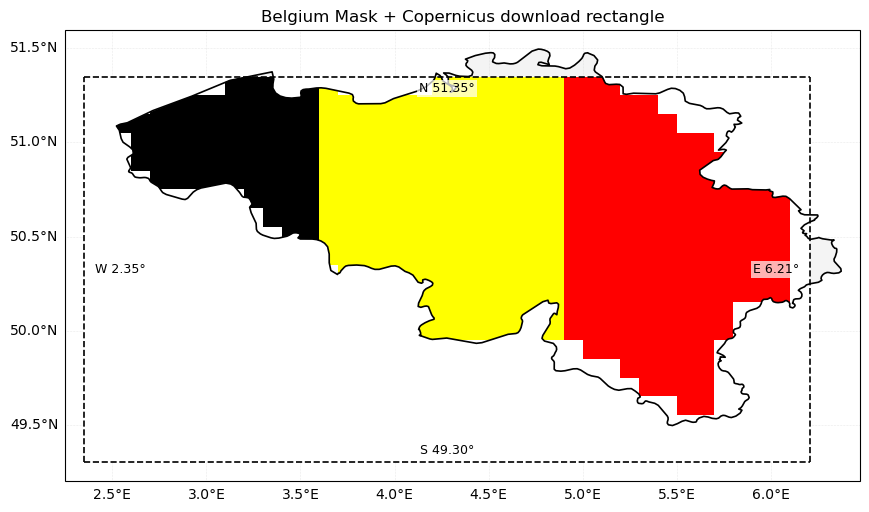

In [1]:
# Belgium mask with Belgian-flag colors + Copernicus download rectangle
# (labels placed INSIDE the rectangle)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
import matplotlib.path as mpath
import cartopy.crs as ccrs
from cartopy.io import shapereader

# Compatibility for different Cartopy versions
try:
    from cartopy.mpl.path import shapely_to_path
except ModuleNotFoundError:
    from cartopy.mpl.patch import geos_to_path

    def shapely_to_path(geom):
        paths = geos_to_path(geom)
        if len(paths) == 1:
            return paths[0]
        return mpath.Path.make_compound_path(*paths)

# ── Config ────────────────────────────────────────────────────────────────
MASK_PATH = "/Users/coralieroland/ACI-Python/data/required_data/mask_BEL.nc"
OUT_PNG   = "BEL_mask_flag_rect.png"
OUT_PDF   = "BEL_mask_flag_rect.pdf"
PAD_DEG   = 0.10

# Copernicus download rectangle
NORTH = 51.35
SOUTH = 49.30
WEST  = 2.35
EAST  = 6.21

# ── Load mask & normalize coordinates ─────────────────────────────────────
ds = xr.open_dataset(MASK_PATH)

if "mask" in ds:
    var_name = "mask"
elif "mask_frac" in ds:
    var_name = "mask_frac"
else:
    raise KeyError("Neither 'mask' nor 'mask_frac' found in the mask file.")

da = ds[var_name]

rename_map = {}
if "lon" in da.coords and "longitude" not in da.coords:
    rename_map["lon"] = "longitude"
if "lat" in da.coords and "latitude" not in da.coords:
    rename_map["lat"] = "latitude"
if rename_map:
    da = da.rename(rename_map)

if "longitude" in da.coords and float(da.longitude.max()) > 180:
    da = da.assign_coords(
        longitude=((da.longitude + 180) % 360) - 180
    ).sortby("longitude")

if "latitude" in da.coords and np.any(np.diff(da.latitude.values) < 0):
    da = da.sortby("latitude")

for dim in list(da.dims):
    if dim not in ("latitude", "longitude"):
        da = da.isel({dim: 0})

# ── Belgium polygon ───────────────────────────────────────────────────────
ne = shapereader.natural_earth("10m", "cultural", "admin_0_countries")
reader = shapereader.Reader(ne)

bel_geom = None
for rec in reader.records():
    a = rec.attributes
    if (
        a.get("ADM0_A3") == "BEL"
        or a.get("ISO_A3") == "BEL"
        or str(a.get("NAME")).upper() == "BELGIUM"
    ):
        bel_geom = rec.geometry
        break

if bel_geom is None:
    raise RuntimeError("Belgium geometry not found in Natural Earth admin_0.")

minx, miny, maxx, maxy = bel_geom.bounds
x0 = min(minx, WEST) - PAD_DEG
x1 = max(maxx, EAST) + PAD_DEG
y0 = min(miny, SOUTH) - PAD_DEG
y1 = max(maxy, NORTH) + PAD_DEG
extent = (x0, x1, y0, y1)

# ── Figure / Axes ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8.8, 6.2))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.add_geometries(
    [bel_geom],
    crs=ccrs.PlateCarree(),
    facecolor="#f4f4f4",
    edgecolor="none",
    zorder=0,
)

# ── Mask fill ─────────────────────────────────────────────────────────────
if var_name == "mask":
    cmap = ListedColormap(["black", "yellow", "red"])
    norm = mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    arr = da.copy()

    lon_min = float(arr.longitude.min().values)
    lon_max = float(arr.longitude.max().values)
    lon_bins = np.linspace(lon_min, lon_max, 4)

    bands_1d = xr.DataArray(
        np.digitize(arr["longitude"].values, lon_bins) - 1,
        dims=["longitude"],
        coords={"longitude": arr["longitude"]},
    )

    _, bands_2d = xr.broadcast(arr, bands_1d)
    colored = bands_2d.where(arr > 0)

    qm = colored.plot.pcolormesh(
        ax=ax,
        x="longitude",
        y="latitude",
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
        rasterized=True,
    )

else:
    arr = da.where(da > 0)

    cmap = LinearSegmentedColormap.from_list(
        "belgium_flag",
        ["black", "yellow", "red"],
    )
    norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)

    qm = arr.plot.pcolormesh(
        ax=ax,
        x="longitude",
        y="latitude",
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=True,
        rasterized=True,
        cbar_kwargs={
            "label": "Mask fraction",
            "shrink": 0.85,
            "pad": 0.02,
        },
    )

# ── Clip mask to Belgium ──────────────────────────────────────────────────
paths = [shapely_to_path(g) for g in getattr(bel_geom, "geoms", [bel_geom])]
comp = mpath.Path.make_compound_path(*paths)

clip_patch = mpatches.PathPatch(
    comp,
    transform=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="none",
)

ax.add_patch(clip_patch)
qm.set_clip_path(clip_patch)

# ── Copernicus rectangle ──────────────────────────────────────────────────
rect_kw = dict(
    transform=ccrs.PlateCarree(),
    color="black",
    linewidth=1.2,
    linestyle="--",
    zorder=12,
)

ax.plot([WEST, WEST], [SOUTH, NORTH], **rect_kw)
ax.plot([EAST, EAST], [SOUTH, NORTH], **rect_kw)
ax.plot([WEST, EAST], [SOUTH, SOUTH], **rect_kw)
ax.plot([WEST, EAST], [NORTH, NORTH], **rect_kw)

# ── Labels inside rectangle ───────────────────────────────────────────────
mid_lon = 0.5 * (WEST + EAST)
mid_lat = 0.5 * (SOUTH + NORTH)

txt_kw = dict(
    transform=ccrs.PlateCarree(),
    fontsize=9,
    color="black",
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.7,
        pad=1.5,
    ),
    zorder=13,
)

dy = 0.03
dx = 0.06

ax.text(
    mid_lon,
    NORTH - dy,
    f"N {NORTH:.2f}°",
    ha="center",
    va="top",
    **txt_kw,
)

ax.text(
    mid_lon,
    SOUTH + dy,
    f"S {SOUTH:.2f}°",
    ha="center",
    va="bottom",
    **txt_kw,
)

ax.text(
    WEST + dx,
    mid_lat,
    f"W {abs(WEST):.2f}°",
    ha="left",
    va="center",
    **txt_kw,
)

ax.text(
    EAST - dx,
    mid_lat,
    f"E {EAST:.2f}°",
    ha="right",
    va="center",
    **txt_kw,
)

# ── Belgium border ────────────────────────────────────────────────────────
ax.add_geometries(
    [bel_geom],
    crs=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="black",
    linewidth=1.2,
    zorder=11,
)

# ── Gridlines ─────────────────────────────────────────────────────────────
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    linestyle=":",
    alpha=0.5,
    zorder=1,
)

gl.right_labels = False
gl.top_labels = False
gl.xlocator = mticker.MultipleLocator(0.5)
gl.ylocator = mticker.MultipleLocator(0.5)
gl.xformatter = LongitudeFormatter(number_format=".1f", degree_symbol="°")
gl.yformatter = LatitudeFormatter(number_format=".1f", degree_symbol="°")

# Hide gridlines inside Copernicus rectangle
grid_cover = mpatches.Rectangle(
    (WEST, SOUTH),
    EAST - WEST,
    NORTH - SOUTH,
    transform=ccrs.PlateCarree(),
    facecolor="white",
    edgecolor="none",
    zorder=5,
)

ax.add_patch(grid_cover)

# Keep mask above grid cover
qm.set_zorder(10)

# ── Title & export ────────────────────────────────────────────────────────
ax.set_title("Belgium Mask + Copernicus download rectangle", fontsize=12)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, dpi=300, bbox_inches="tight")

print(f"Saved: {OUT_PNG} and {OUT_PDF}")

plt.show()


Plot saved as precipitation_bars_and_moving_avg_fullwindow.png


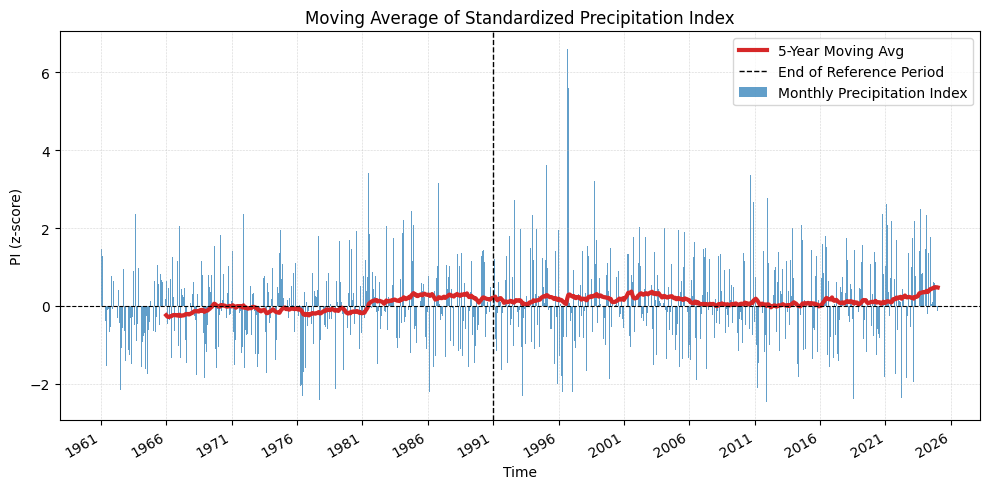


📊 Precipitation Index — Summary Statistics
count       768
mean      0.095
std       1.102
min      -2.471  at 2011-11
5%       -1.579
25%      -0.643
50%       0.028
75%       0.768
95%       1.961
max       6.599  at 1996-08
skewness:  0.622
kurtosis:  1.963  (excess)

⚠️  Moderate‐event frequency (1σ < |PI| ≤ 2σ)
 221 / 768   (28.8%)

🚨 Extreme‐event frequency (|PI| > 2σ)
  49 / 768   ( 6.4%)


In [3]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1) Load cleaned Precipitation Index ──────────────────────────────────
# Expected path for your country-mean monthly precipitation index (SPI-like, standardized)
PI_PATH = "ACI-Python/data/composites/precipitation_index.nc"

# Try to open as DataArray first (typical for saved index); fallback to Dataset
try:
    da = xr.open_dataarray(PI_PATH)
except Exception:
    ds = xr.open_dataset(PI_PATH)
    # If it's a Dataset with multiple vars (e.g., stations), combine → mean
    da = ds.to_array(name="precipitation_index")  # dims: ("variable","time")
    da = da.mean(dim="variable", skipna=True)

# ── 2) Ensure 1-D monthly series (collapse 'step' if present) ────────────
if "step" in da.dims:
    da = da.mean(dim="step")

# ── 3) Clean to study period and drop NaNs ───────────────────────────────
pi_series = (
    da
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# OPTIONAL: align to month-end for cleaner bar placement
# pi_series.index = pi_series.index.to_period("M").to_timestamp("M")

# ── 4) Right-aligned 60-month rolling mean (full window only) ────────────
rolling_60 = (
    pi_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 5) Plot bars + moving average (minimal model) ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly PI bars (SPI-like standardized precipitation index)
ax.bar(
    pi_series.index,
    pi_series.values,
    width=25,
    color="tab:blue",
    alpha=0.7,
    label="Monthly Precipitation Index"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# End of reference period (common for ACI: 1961–1990)
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# Cosmetics
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized Precipitation Index")
ax.set_xlabel("Time")
ax.set_ylabel("PI (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# Custom 5-year x-axis ticks
years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 6) Save figure ───────────────────────────────────────────────────────
fig.savefig("precipitation_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as precipitation_bars_and_moving_avg_fullwindow.png")

plt.show()

# ── 7) Console statistics (same style as wind/t10/sealevel) ──────────────
desc = pi_series.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = pi_series.skew()
kurt = pi_series.kurt()  # excess kurtosis (0 for normal)

n_tot = pi_series.size
n_mod = int(((pi_series.abs() > 1.0) & (pi_series.abs() <= 2.0)).sum())
n_ext = int((pi_series.abs() > 2.0).sum())

tmin = pi_series.idxmin()
tmax = pi_series.idxmax()

print("\n📊 Precipitation Index — Summary Statistics")
print(f"count   {int(desc['count']):>7d}")
print(f"mean    {desc['mean']:>7.3f}")
print(f"std     {desc['std']:>7.3f}")
print(f"min     {desc['min']:>7.3f}  at {tmin:%Y-%m}")
print(f"5%      {desc['5%']:>7.3f}")
print(f"25%     {desc['25%']:>7.3f}")
print(f"50%     {desc['50%']:>7.3f}")
print(f"75%     {desc['75%']:>7.3f}")
print(f"95%     {desc['95%']:>7.3f}")
print(f"max     {desc['max']:>7.3f}  at {tmax:%Y-%m}")
print(f"skewness: {skew:>6.3f}")
print(f"kurtosis: {kurt:>6.3f}  (excess)")

print("\n⚠️  Moderate‐event frequency (1σ < |PI| ≤ 2σ)")
print(f"{n_mod:>4d} / {n_tot:<4d}  ({n_mod/n_tot*100:>4.1f}%)")

print("\n🚨 Extreme‐event frequency (|PI| > 2σ)")
print(f"{n_ext:>4d} / {n_tot:<4d}  ({n_ext/n_tot*100:>4.1f}%)")


Plot saved as t90_bars_and_moving_avg_fullwindow.png


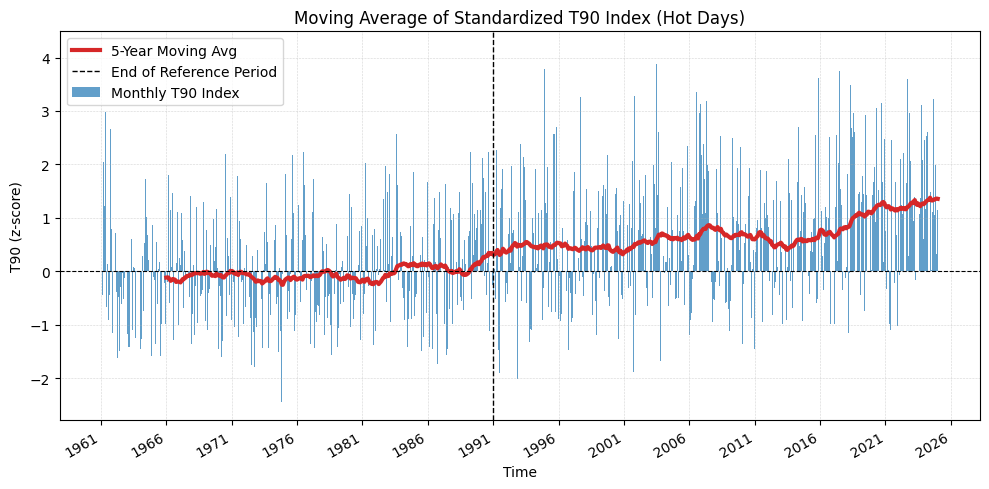


📊 T90 Index — Summary Statistics
count       768
mean      0.401
std       1.179
min      -2.452  at 1974-10
5%       -1.339
25%      -0.499
50%       0.271
75%       1.195
95%       2.516
max       4.159  at 2023-06
skewness:  0.448
kurtosis: -0.172  (excess)

⚠️  Moderate‐event frequency (1σ < |T90| ≤ 2σ)
 243 / 768   (31.6%)

🚨 Extreme‐event frequency (|T90| > 2σ)
  74 / 768   ( 9.6%)


In [4]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1) Load cleaned T90 Index ────────────────────────────────────────────
T90_PATH = "ACI-Python/data/composites/t90_index.nc"

# Try to open as DataArray (usual case for saved index); fallback to Dataset
try:
    da = xr.open_dataarray(T90_PATH)
except Exception:
    ds = xr.open_dataset(T90_PATH)
    da = ds.to_array(name="t90_index")       # dims: ("variable","time")
    da = da.mean(dim="variable", skipna=True)

# ── 2) Ensure 1-D monthly series (collapse 'step' if present) ─────────────
if "step" in da.dims:
    da = da.mean(dim="step")

# ── 3) Clean to study period and drop NaNs ───────────────────────────────
t90_series = (
    da
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# OPTIONAL: align to month-end for cleaner bar placement
# t90_series.index = t90_series.index.to_period("M").to_timestamp("M")

# ── 4) Right-aligned 60-month rolling mean (full window only) ────────────
rolling_60 = (
    t90_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 5) Plot bars + moving average ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly T90 bars
ax.bar(
    t90_series.index,
    t90_series.values,
    width=25,
    color="tab:blue",
    alpha=0.7,
    label="Monthly T90 Index"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# End of reference period (common for ACI: 1961–1990)
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# Cosmetics
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized T90 Index (Hot Days)")
ax.set_xlabel("Time")
ax.set_ylabel("T90 (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# Custom 5-year x-axis ticks
years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 6) Save figure ───────────────────────────────────────────────────────
fig.savefig("t90_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as t90_bars_and_moving_avg_fullwindow.png")

plt.show()

# ── 7) Console statistics ────────────────────────────────────────────────
desc = t90_series.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = t90_series.skew()
kurt = t90_series.kurt()  # excess kurtosis (0 for normal)

n_tot = t90_series.size
n_mod = int(((t90_series.abs() > 1.0) & (t90_series.abs() <= 2.0)).sum())
n_ext = int((t90_series.abs() > 2.0).sum())

tmin = t90_series.idxmin()
tmax = t90_series.idxmax()

print("\n📊 T90 Index — Summary Statistics")
print(f"count   {int(desc['count']):>7d}")
print(f"mean    {desc['mean']:>7.3f}")
print(f"std     {desc['std']:>7.3f}")
print(f"min     {desc['min']:>7.3f}  at {tmin:%Y-%m}")
print(f"5%      {desc['5%']:>7.3f}")
print(f"25%     {desc['25%']:>7.3f}")
print(f"50%     {desc['50%']:>7.3f}")
print(f"75%     {desc['75%']:>7.3f}")
print(f"95%     {desc['95%']:>7.3f}")
print(f"max     {desc['max']:>7.3f}  at {tmax:%Y-%m}")
print(f"skewness: {skew:>6.3f}")
print(f"kurtosis: {kurt:>6.3f}  (excess)")

print("\n⚠️  Moderate‐event frequency (1σ < |T90| ≤ 2σ)")
print(f"{n_mod:>4d} / {n_tot:<4d}  ({n_mod/n_tot*100:>4.1f}%)")

print("\n🚨 Extreme‐event frequency (|T90| > 2σ)")
print(f"{n_ext:>4d} / {n_tot:<4d}  ({n_ext/n_tot*100:>4.1f}%)")


Plot saved as t10_bars_and_moving_avg_fullwindow.png


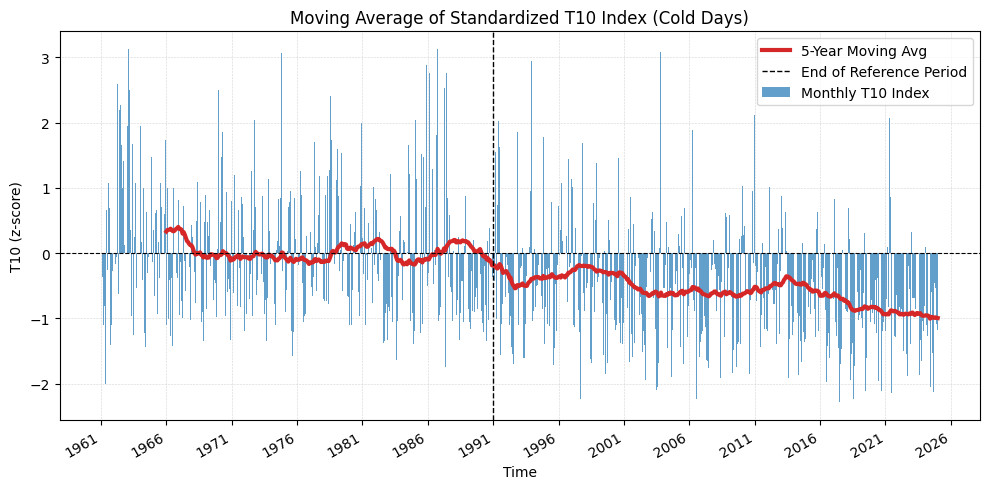


📊 T10 Index — Summary Statistics
count       768
mean     -0.326
std       1.003
min      -2.285  at 2017-06
5%       -1.685
25%      -1.046
50%      -0.512
75%       0.239
95%       1.649
max       3.126  at 1963-01
skewness:  0.811
kurtosis:  0.621  (excess)

⚠️  Moderate‐event frequency (1σ < |T10| ≤ 2σ)
 250 / 768   (32.6%)

🚨 Extreme‐event frequency (|T10| > 2σ)
  33 / 768   ( 4.3%)


In [5]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1) Load cleaned T10 Index ────────────────────────────────────────────
T10_PATH = "ACI-Python/data/composites/t10_index.nc"

# Try to open as DataArray (usual case); fallback to Dataset
try:
    da = xr.open_dataarray(T10_PATH)
except Exception:
    ds = xr.open_dataset(T10_PATH)
    da = ds.to_array(name="t10_index")        # dims: ("variable","time")
    da = da.mean(dim="variable", skipna=True)

# ── 2) Ensure 1-D monthly series (collapse 'step' if present) ─────────────
if "step" in da.dims:
    da = da.mean(dim="step")

# ── 3) Clean to study period and drop NaNs ───────────────────────────────
t10_series = (
    da
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# OPTIONAL: align to month-end for cleaner bar placement
# t10_series.index = t10_series.index.to_period("M").to_timestamp("M")

# ── 4) Right-aligned 60-month rolling mean (full window only) ────────────
rolling_60 = (
    t10_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 5) Plot bars + moving average ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly T10 bars
ax.bar(
    t10_series.index,
    t10_series.values,
    width=25,
    color="tab:blue",   # blue → cold days
    alpha=0.7,
    label="Monthly T10 Index"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# End of reference period
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# Cosmetics
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized T10 Index (Cold Days)")
ax.set_xlabel("Time")
ax.set_ylabel("T10 (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# Custom 5-year x-axis ticks
years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 6) Save figure ───────────────────────────────────────────────────────
fig.savefig("t10_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as t10_bars_and_moving_avg_fullwindow.png")

plt.show()

# ── 7) Console statistics ────────────────────────────────────────────────
desc = t10_series.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = t10_series.skew()
kurt = t10_series.kurt()  # excess kurtosis

n_tot = t10_series.size
n_mod = int(((t10_series.abs() > 1.0) & (t10_series.abs() <= 2.0)).sum())
n_ext = int((t10_series.abs() > 2.0).sum())

tmin = t10_series.idxmin()
tmax = t10_series.idxmax()

print("\n📊 T10 Index — Summary Statistics")
print(f"count   {int(desc['count']):>7d}")
print(f"mean    {desc['mean']:>7.3f}")
print(f"std     {desc['std']:>7.3f}")
print(f"min     {desc['min']:>7.3f}  at {tmin:%Y-%m}")
print(f"5%      {desc['5%']:>7.3f}")
print(f"25%     {desc['25%']:>7.3f}")
print(f"50%     {desc['50%']:>7.3f}")
print(f"75%     {desc['75%']:>7.3f}")
print(f"95%     {desc['95%']:>7.3f}")
print(f"max     {desc['max']:>7.3f}  at {tmax:%Y-%m}")
print(f"skewness: {skew:>6.3f}")
print(f"kurtosis: {kurt:>6.3f}  (excess)")

print("\n⚠️  Moderate‐event frequency (1σ < |T10| ≤ 2σ)")
print(f"{n_mod:>4d} / {n_tot:<4d}  ({n_mod/n_tot*100:>4.1f}%)")

print("\n🚨 Extreme‐event frequency (|T10| > 2σ)")
print(f"{n_ext:>4d} / {n_tot:<4d}  ({n_ext/n_tot*100:>4.1f}%)")


Plot saved as temperature_bars_and_moving_avg_fullwindow.png


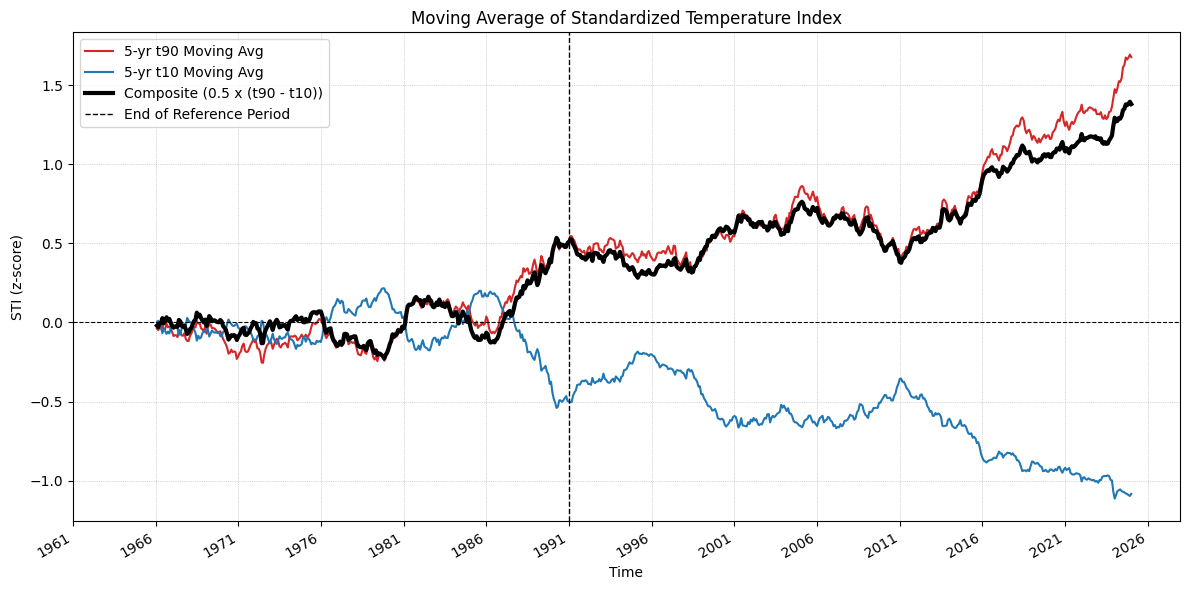

In [6]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1. Load your saved indices (1961 onward) ─────────────────────────────
t90 = (
    xr.open_dataarray("ACI-Python/data/composites/t90_index.nc")
      .sel(time=slice("1961-01-01", None))
      .to_series()
      .dropna()
)
t10 = (
    xr.open_dataarray("ACI-Python/data/composites/t10_index.nc")
      .sel(time=slice("1961-01-01", None))
      .to_series()
      .dropna()
)

# ── 2. Compute composite series ────────────────────────────────────────────
comp = (0.5 * (t90 - t10)).dropna()

# ── 3. Compute 60-month centered rolling means ─────────────────────────────
r90 = t90.rolling(window=60, center=True, min_periods=1).mean()
r10 = t10.rolling(window=60, center=True, min_periods=1).mean()
rc  = comp.rolling(window=60, center=True, min_periods=1).mean()

# ── 4. Restrict rolling-mean to 1966–2024 ────────────────────────────────
r90 = r90.loc["1966-01-01":"2024-12-31"]
r10 = r10.loc["1966-01-01":"2024-12-31"]
rc  = rc.loc["1966-01-01":"2024-12-31"]

# ── 5. Plot only the rolling means ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(r90.index, r90.values, color='tab:red',   linewidth=1.5, label='5-yr t90 Moving Avg')
ax.plot(r10.index, r10.values, color='tab:blue',  linewidth=1.5, label='5-yr t10 Moving Avg')
ax.plot(rc.index,  rc.values,  color='black',  linewidth=3, label='Composite (0.5 x (t90 - t10))')

# ── Reference-period end marker ───────────────────────────────────────────
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color='black', linestyle='--', linewidth=1, label='End of Reference Period')

# ── Zero line & grid ──────────────────────────────────────────────────────
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.grid(True, linestyle=":", linewidth=0.5)

# ── Labels & title ────────────────────────────────────────────────────────
ax.set_title("Moving Average of Standardized Temperature Index")
ax.set_xlabel("Time")
ax.set_ylabel("STI (z-score)")

# ── 5-year x-ticks from 1961 to 2026 ─────────────────────────────────────
years = list(range(1961, 2027, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

# ── Legend & layout ───────────────────────────────────────────────────────
ax.legend(loc='upper left')
plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────────────
fig.savefig("temperature_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as temperature_bars_and_moving_avg_fullwindow.png")

plt.show()

Plot saved as composite_t90_t10_bars_and_moving_avg.png


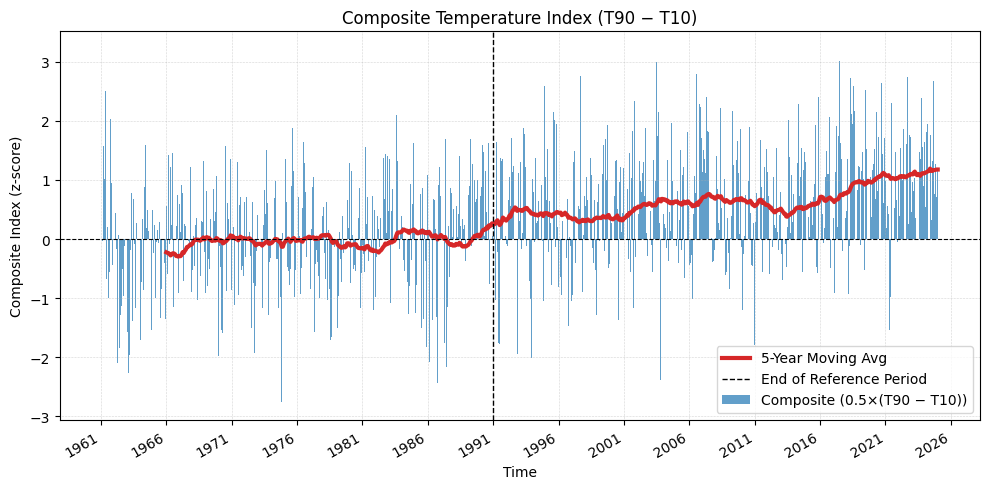


📊 Composite T90–T10 Index — Summary Statistics
count       768
mean      0.363
std       1.015
min      -2.758  at 1974-10
5%       -1.356
25%      -0.320
50%       0.362
75%       1.090
95%       1.942
max       3.213  at 2023-06
skewness: -0.085
kurtosis: -0.151  (excess)

⚠️  Moderate‐event frequency (1σ < |Composite| ≤ 2σ)
 245 / 768   (31.9%)

🚨 Extreme‐event frequency (|Composite| > 2σ)
  44 / 768   ( 5.7%)


In [7]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1) Load cleaned T90 and T10 indices ──────────────────────────────────
T90_PATH = "ACI-Python/data/composites/t90_index.nc"
T10_PATH = "ACI-Python/data/composites/t10_index.nc"

# Open both (DataArray or Dataset fallback)
def open_index(path, name):
    try:
        da = xr.open_dataarray(path)
    except Exception:
        ds = xr.open_dataset(path)
        da = ds.to_array(name=name).mean(dim="variable", skipna=True)
    if "step" in da.dims:
        da = da.mean(dim="step")
    return da.sel(time=slice("1961-01-01", None)).to_series().dropna()

t90 = open_index(T90_PATH, "t90_index")
t10 = open_index(T10_PATH, "t10_index")

# ── 2) Compute composite series ──────────────────────────────────────────
comp = (0.5 * (t90 - t10)).dropna()

# ── 3) Right-aligned 60-month rolling mean ───────────────────────────────
rolling_60 = (
    comp
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 4) Plot bars + moving average ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Composite index bars
ax.bar(
    comp.index,
    comp.values,
    width=25,
    color="tab:blue",
    alpha=0.7,
    label="Composite (0.5×(T90 − T10))"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# End of reference period
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# Cosmetics
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Composite Temperature Index (T90 − T10)")
ax.set_xlabel("Time")
ax.set_ylabel("Composite Index (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# Custom 5-year x-axis ticks
years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 5) Save figure ───────────────────────────────────────────────────────
fig.savefig("composite_t90_t10_bars_and_moving_avg.png", dpi=300, bbox_inches="tight")
print("Plot saved as composite_t90_t10_bars_and_moving_avg.png")

plt.show()

# ── 6) Console statistics ────────────────────────────────────────────────
desc = comp.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = comp.skew()
kurt = comp.kurt()  # excess kurtosis

n_tot = comp.size
n_mod = int(((comp.abs() > 1.0) & (comp.abs() <= 2.0)).sum())
n_ext = int((comp.abs() > 2.0).sum())

tmin = comp.idxmin()
tmax = comp.idxmax()

print("\n📊 Composite T90–T10 Index — Summary Statistics")
print(f"count   {int(desc['count']):>7d}")
print(f"mean    {desc['mean']:>7.3f}")
print(f"std     {desc['std']:>7.3f}")
print(f"min     {desc['min']:>7.3f}  at {tmin:%Y-%m}")
print(f"5%      {desc['5%']:>7.3f}")
print(f"25%     {desc['25%']:>7.3f}")
print(f"50%     {desc['50%']:>7.3f}")
print(f"75%     {desc['75%']:>7.3f}")
print(f"95%     {desc['95%']:>7.3f}")
print(f"max     {desc['max']:>7.3f}  at {tmax:%Y-%m}")
print(f"skewness: {skew:>6.3f}")
print(f"kurtosis: {kurt:>6.3f}  (excess)")

print("\n⚠️  Moderate‐event frequency (1σ < |Composite| ≤ 2σ)")
print(f"{n_mod:>4d} / {n_tot:<4d}  ({n_mod/n_tot*100:>4.1f}%)")

print("\n🚨 Extreme‐event frequency (|Composite| > 2σ)")
print(f"{n_ext:>4d} / {n_tot:<4d}  ({n_ext/n_tot*100:>4.1f}%)")


Plot saved as NEWtemperature_bars_and_moving_avg_fullwindow.png


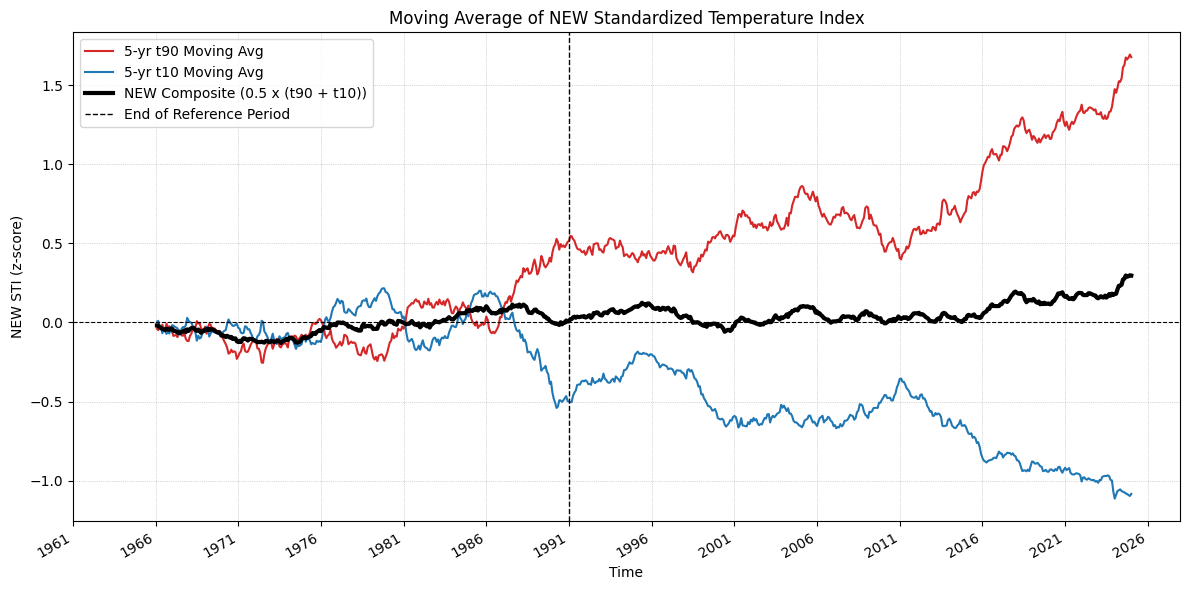

In [8]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1. Load your saved indices (1961 onward) ─────────────────────────────
t90 = (
    xr.open_dataarray("ACI-Python/data/composites/t90_index.nc")
      .sel(time=slice("1961-01-01", None))
      .to_series()
      .dropna()
)
t10 = (
    xr.open_dataarray("ACI-Python/data/composites/t10_index.nc")
      .sel(time=slice("1961-01-01", None))
      .to_series()
      .dropna()
)

# ── 2. Compute composite series ────────────────────────────────────────────
comp = (0.5 * (t90 + t10)).dropna()

# ── 3. Compute 60-month centered rolling means ─────────────────────────────
r90 = t90.rolling(window=60, center=True, min_periods=1).mean()
r10 = t10.rolling(window=60, center=True, min_periods=1).mean()
rc  = comp.rolling(window=60, center=True, min_periods=1).mean()

# ── 4. Restrict rolling-mean to 1966–2024 ────────────────────────────────
r90 = r90.loc["1966-01-01":"2024-12-31"]
r10 = r10.loc["1966-01-01":"2024-12-31"]
rc  = rc.loc["1966-01-01":"2024-12-31"]

# ── 5. Plot only the rolling means ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(r90.index, r90.values, color='tab:red',   linewidth=1.5, label='5-yr t90 Moving Avg')
ax.plot(r10.index, r10.values, color='tab:blue',  linewidth=1.5, label='5-yr t10 Moving Avg')
ax.plot(rc.index,  rc.values,  color='black',  linewidth=3, label='NEW Composite (0.5 x (t90 + t10))')

# ── Reference-period end marker ───────────────────────────────────────────
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color='black', linestyle='--', linewidth=1, label='End of Reference Period')

# ── Zero line & grid ──────────────────────────────────────────────────────
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.grid(True, linestyle=":", linewidth=0.5)

# ── Labels & title ────────────────────────────────────────────────────────
ax.set_title("Moving Average of NEW Standardized Temperature Index")
ax.set_xlabel("Time")
ax.set_ylabel("NEW STI (z-score)")

# ── 5-year x-ticks from 1961 to 2026 ─────────────────────────────────────
years = list(range(1961, 2027, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

# ── Legend & layout ───────────────────────────────────────────────────────
ax.legend(loc='upper left')
plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────────────
fig.savefig("NEWtemperature_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as NEWtemperature_bars_and_moving_avg_fullwindow.png")

plt.show()

Plot saved as composite_t90_plus_t10_bars_and_moving_avg.png


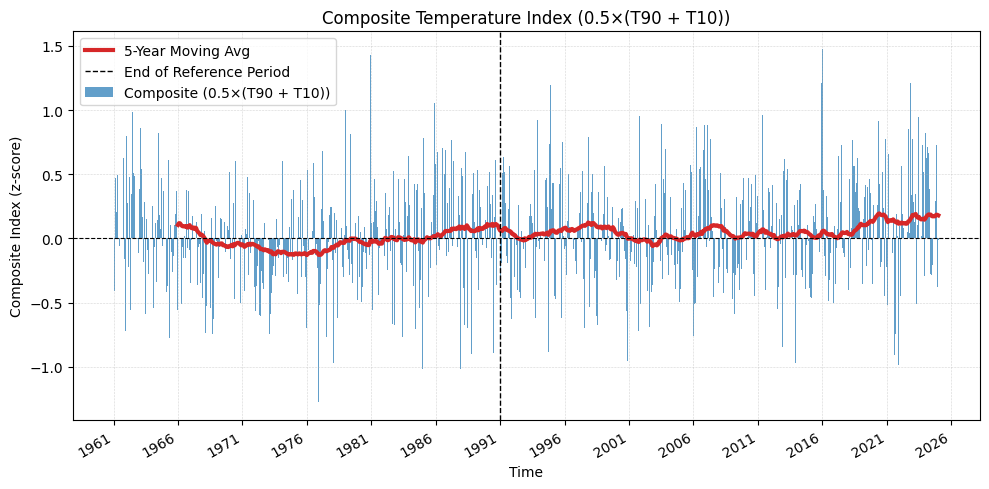


📊 Composite (0.5×(T90 + T10)) — Summary Statistics
count       768
mean      0.038
std       0.409
min      -1.276  at 1976-11
5%       -0.614
25%      -0.235
50%       0.018
75%       0.323
95%       0.721
max       1.476  at 2015-12
skewness:  0.133
kurtosis:  0.135  (excess)

⚠️  Moderate‐event frequency (1σ < |Composite| ≤ 2σ)
  11 / 768   ( 1.4%)

🚨 Extreme‐event frequency (|Composite| > 2σ)
   0 / 768   ( 0.0%)


In [9]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1) Load cleaned T90 and T10 indices ──────────────────────────────────
T90_PATH = "ACI-Python/data/composites/t90_index.nc"
T10_PATH = "ACI-Python/data/composites/t10_index.nc"

def open_index(path, name):
    try:
        da = xr.open_dataarray(path)
    except Exception:
        ds = xr.open_dataset(path)
        da = ds.to_array(name=name).mean(dim="variable", skipna=True)
    if "step" in da.dims:
        da = da.mean(dim="step")
    return (
        da.sel(time=slice("1961-01-01", None))
          .to_series()
          .dropna()
    )

t90 = open_index(T90_PATH, "t90_index")
t10 = open_index(T10_PATH, "t10_index")

# Ensure aligned monthly indices (inner join on dates)
t90, t10 = t90.align(t10, join="inner")

# ── 2) Compute composite series ──────────────────────────────────────────
comp = (0.5 * (t90 + t10)).dropna()

# ── 3) Right-aligned 60-month rolling mean ───────────────────────────────
rolling_60 = (
    comp.rolling(window=60, center=False, min_periods=60)
        .mean()
        .dropna()
)

# ── 4) Plot bars + moving average ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    comp.index, comp.values,
    width=25, color="tab:blue", alpha=0.7,
    label="Composite (0.5×(T90 + T10))"
)

ax.plot(
    rolling_60.index, rolling_60.values,
    color="tab:red", linewidth=3, label="5-Year Moving Avg"
)

ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Composite Temperature Index (0.5×(T90 + T10))")
ax.set_xlabel("Time")
ax.set_ylabel("Composite Index (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 5) Save figure ───────────────────────────────────────────────────────
fig.savefig("composite_t90_plus_t10_bars_and_moving_avg.png", dpi=300, bbox_inches="tight")
print("Plot saved as composite_t90_plus_t10_bars_and_moving_avg.png")

plt.show()

# ── 6) Console statistics ────────────────────────────────────────────────
desc = comp.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = comp.skew()
kurt = comp.kurt()  # excess kurtosis

n_tot = comp.size
n_mod = int(((comp.abs() > 1.0) & (comp.abs() <= 2.0)).sum())
n_ext = int((comp.abs() > 2.0).sum())

tmin = comp.idxmin()
tmax = comp.idxmax()

print("\n📊 Composite (0.5×(T90 + T10)) — Summary Statistics")
print(f"count   {int(desc['count']):>7d}")
print(f"mean    {desc['mean']:>7.3f}")
print(f"std     {desc['std']:>7.3f}")
print(f"min     {desc['min']:>7.3f}  at {tmin:%Y-%m}")
print(f"5%      {desc['5%']:>7.3f}")
print(f"25%     {desc['25%']:>7.3f}")
print(f"50%     {desc['50%']:>7.3f}")
print(f"75%     {desc['75%']:>7.3f}")
print(f"95%     {desc['95%']:>7.3f}")
print(f"max     {desc['max']:>7.3f}  at {tmax:%Y-%m}")
print(f"skewness: {skew:>6.3f}")
print(f"kurtosis: {kurt:>6.3f}  (excess)")

print("\n⚠️  Moderate‐event frequency (1σ < |Composite| ≤ 2σ)")
print(f"{n_mod:>4d} / {n_tot:<4d}  ({n_mod/n_tot*100:>4.1f}%)")

print("\n🚨 Extreme‐event frequency (|Composite| > 2σ)")
print(f"{n_ext:>4d} / {n_tot:<4d}  ({n_ext/n_tot*100:>4.1f}%)")


Plot saved as wind_bars_and_moving_avg_fullwindow.png


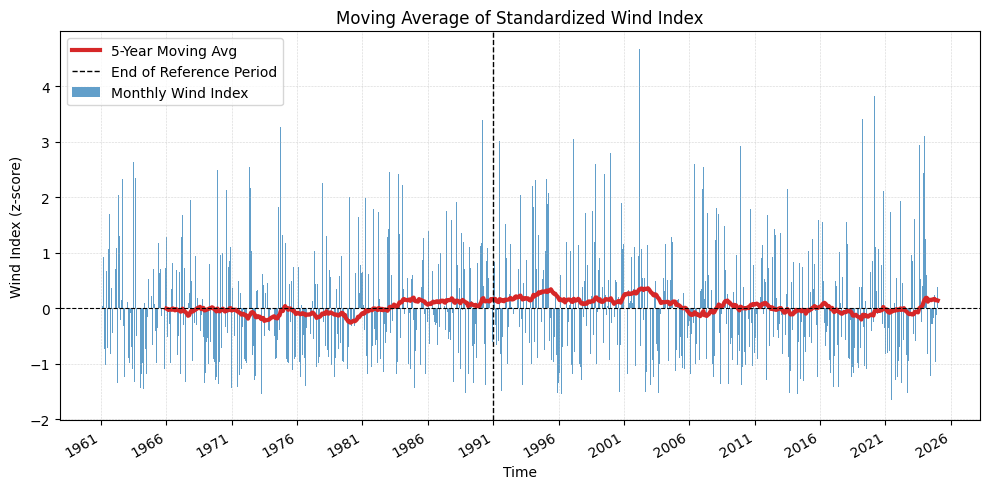


📊 Wind Index — Summary Statistics
count       768
mean      0.031
std       1.040
min      -1.697  at 2023-06
5%       -1.328
25%      -0.793
50%      -0.141
75%       0.648
95%       2.040
max       4.675  at 2002-02
skewness:  0.873
kurtosis:  0.649  (excess)

⚠️  Moderate‐event frequency (1σ < |Wind| ≤ 2σ)
 207 / 768   (27.0%)

🚨 Extreme‐event frequency (|Wind| > 2σ)
  40 / 768   ( 5.2%)


In [10]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1) Load cleaned Wind Index ───────────────────────────────────────────
WIND_PATH = "ACI-Python/data/composites/wind_index.nc"

# Try to open as DataArray (usual case); fallback to Dataset
try:
    da = xr.open_dataarray(WIND_PATH)
except Exception:
    ds = xr.open_dataset(WIND_PATH)
    da = ds.to_array(name="wind_index")        # dims: ("variable","time")
    da = da.mean(dim="variable", skipna=True)

# ── 2) Ensure 1-D monthly series (collapse 'step' if present) ─────────────
if "step" in da.dims:
    da = da.mean(dim="step")

# ── 3) Clean to study period and drop NaNs ───────────────────────────────
wind_series = (
    da
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# ── 4) Right-aligned 60-month rolling mean (full window only) ────────────
rolling_60 = (
    wind_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 5) Plot bars + moving average ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly wind index bars
ax.bar(
    wind_series.index,
    wind_series.values,
    width=25,
    color="tab:blue",
    alpha=0.7,
    label="Monthly Wind Index"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# End of reference period
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# Cosmetics
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized Wind Index")
ax.set_xlabel("Time")
ax.set_ylabel("Wind Index (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# Custom 5-year x-axis ticks
years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 6) Save figure ───────────────────────────────────────────────────────
fig.savefig("wind_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as wind_bars_and_moving_avg_fullwindow.png")

plt.show()

# ── 7) Console statistics ────────────────────────────────────────────────
desc = wind_series.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = wind_series.skew()
kurt = wind_series.kurt()  # excess kurtosis

n_tot = wind_series.size
n_mod = int(((wind_series.abs() > 1.0) & (wind_series.abs() <= 2.0)).sum())
n_ext = int((wind_series.abs() > 2.0).sum())

tmin = wind_series.idxmin()
tmax = wind_series.idxmax()

print("\n📊 Wind Index — Summary Statistics")
print(f"count   {int(desc['count']):>7d}")
print(f"mean    {desc['mean']:>7.3f}")
print(f"std     {desc['std']:>7.3f}")
print(f"min     {desc['min']:>7.3f}  at {tmin:%Y-%m}")
print(f"5%      {desc['5%']:>7.3f}")
print(f"25%     {desc['25%']:>7.3f}")
print(f"50%     {desc['50%']:>7.3f}")
print(f"75%     {desc['75%']:>7.3f}")
print(f"95%     {desc['95%']:>7.3f}")
print(f"max     {desc['max']:>7.3f}  at {tmax:%Y-%m}")
print(f"skewness: {skew:>6.3f}")
print(f"kurtosis: {kurt:>6.3f}  (excess)")

print("\n⚠️  Moderate‐event frequency (1σ < |Wind| ≤ 2σ)")
print(f"{n_mod:>4d} / {n_tot:<4d}  ({n_mod/n_tot*100:>4.1f}%)")

print("\n🚨 Extreme‐event frequency (|Wind| > 2σ)")
print(f"{n_ext:>4d} / {n_tot:<4d}  ({n_ext/n_tot*100:>4.1f}%)")


Plot saved as sealevel_bars_and_moving_avg_fullwindow.png


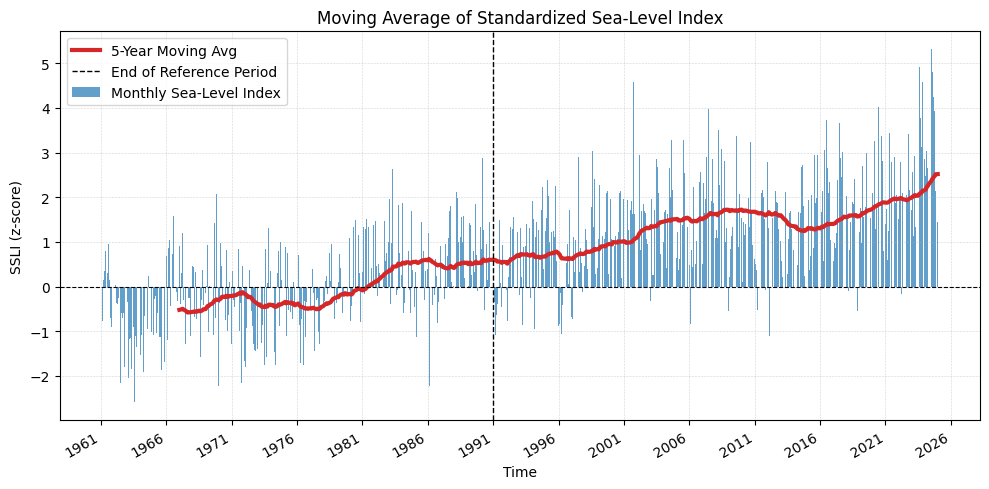


📊 Sea-Level Index — Summary Statistics
count       640
mean      0.808
std       1.324
min      -2.587  at 1963-07
5%       -1.180
25%      -0.182
50%       0.821
75%       1.678
95%       3.027
max       5.319  at 2024-06
skewness:  0.256
kurtosis:  0.006  (excess)

⚠️  Moderate‐event frequency (1σ < |SSLI| ≤ 2σ)
 228 / 640   (35.6%)

🚨 Extreme‐event frequency (|SSLI| > 2σ)
 114 / 640   (17.8%)


In [11]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# ── 1) Load cleaned Sea-Level Index ─────────────────────────────────────
ds = xr.open_dataset("ACI-Python/data/composites/sealevel_index.nc")

# ── 2) Combine gauges → single monthly series (mean across variables) ───
da = ds.to_array(name="sealevel_index")           # dims: ("variable","time")
da_mean = da.mean(dim="variable", skipna=True)

# (If present) collapse over 'step' → 1-D monthly series
if "step" in da_mean.dims:
    da_mean = da_mean.mean(dim="step")

# ── 3) Clean to study period and drop NaNs ──────────────────────────────
sl_series = (
    da_mean
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# OPTIONAL: align to month-end for cleaner bar placement
# sl_series.index = sl_series.index.to_period("M").to_timestamp("M")

# ── 4) Right-aligned 60-month rolling mean (full window only) ───────────
rolling_60 = (
    sl_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 5) Plot bars + moving average (minimal model) ───────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly SSLI bars
ax.bar(
    sl_series.index,
    sl_series.values,
    width=25,
    color="tab:blue",
    alpha=0.7,
    label="Monthly Sea-Level Index"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# End of reference period
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# Cosmetics
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized Sea-Level Index")
ax.set_xlabel("Time")
ax.set_ylabel("SSLI (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# Custom 5-year x-axis ticks
years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 6) Save figure ──────────────────────────────────────────────────────
fig.savefig("sealevel_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as sealevel_bars_and_moving_avg_fullwindow.png")

plt.show()

# ── 7) Console statistics (like wind/t10) ───────────────────────────────
desc = sl_series.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = sl_series.skew()
kurt = sl_series.kurt()  # excess kurtosis (0 for normal)

n_tot = sl_series.size
n_mod = int(((sl_series.abs() > 1.0) & (sl_series.abs() <= 2.0)).sum())
n_ext = int((sl_series.abs() > 2.0).sum())

tmin = sl_series.idxmin()
tmax = sl_series.idxmax()

print("\n📊 Sea-Level Index — Summary Statistics")
print(f"count   {int(desc['count']):>7d}")
print(f"mean    {desc['mean']:>7.3f}")
print(f"std     {desc['std']:>7.3f}")
print(f"min     {desc['min']:>7.3f}  at {tmin:%Y-%m}")
print(f"5%      {desc['5%']:>7.3f}")
print(f"25%     {desc['25%']:>7.3f}")
print(f"50%     {desc['50%']:>7.3f}")
print(f"75%     {desc['75%']:>7.3f}")
print(f"95%     {desc['95%']:>7.3f}")
print(f"max     {desc['max']:>7.3f}  at {tmax:%Y-%m}")
print(f"skewness: {skew:>6.3f}")
print(f"kurtosis: {kurt:>6.3f}  (excess)")

print("\n⚠️  Moderate‐event frequency (1σ < |SSLI| ≤ 2σ)")
print(f"{n_mod:>4d} / {n_tot:<4d}  ({n_mod/n_tot*100:>4.1f}%)")

print("\n🚨 Extreme‐event frequency (|SSLI| > 2σ)")
print(f"{n_ext:>4d} / {n_tot:<4d}  ({n_ext/n_tot*100:>4.1f}%)")



Plot saved as drought_bars_and_moving_avg_fullwindow.png


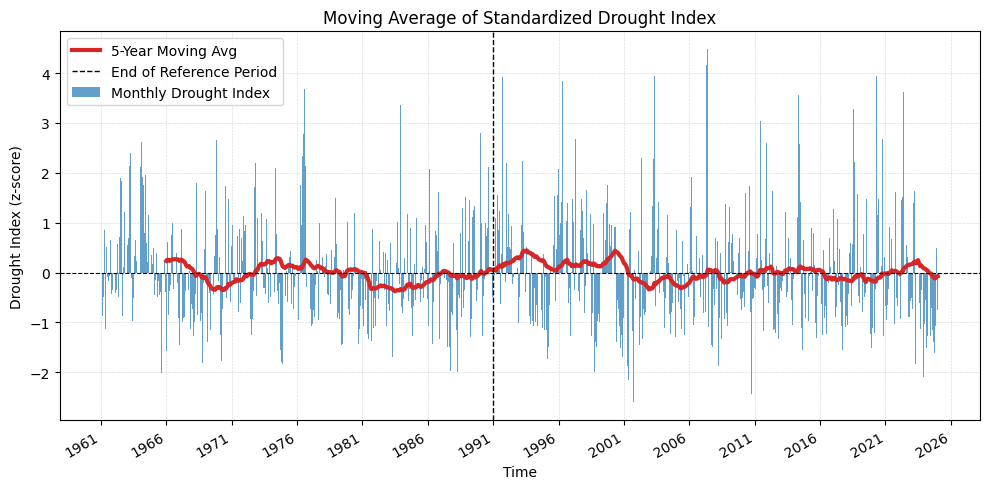


📊 Drought Index — Summary Statistics
count       768
mean     -0.006
std       1.089
min      -2.599  at 2001-09
5%       -1.444
25%      -0.788
50%      -0.189
75%       0.617
95%       2.078
max       4.483  at 2007-05
skewness:  0.944
kurtosis:  1.346  (excess)

⚠️  Moderate‐event frequency (1σ < |Index| ≤ 2σ)
 197 / 768   (25.7%)

🚨 Extreme‐event frequency (|Index| > 2σ)
  47 / 768   ( 6.1%)


In [12]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

PATH = "ACI-Python/data/composites/drought_index.nc"

# ── 1) Load cleaned Drought Index ────────────────────────────────────────
try:
    da = xr.open_dataarray(PATH)
except Exception:
    ds = xr.open_dataset(PATH)
    if len(ds.data_vars) > 1:
        da = ds.to_array(name="drought_index").mean(dim="variable", skipna=True)
    else:
        da = ds[list(ds.data_vars)[0]]
    ds.close()

# ── 2) Collapse non-time dims (e.g. 'step') ──────────────────────────────
time_dim = "time" if "time" in da.dims else da.dims[0]
other_dims = [d for d in da.dims if d != time_dim]
if other_dims:
    da = da.mean(dim=other_dims, skipna=True)

# ── 3) Study period and Series conversion ────────────────────────────────
drought_series = (
    da
    .sel({time_dim: slice("1961-01-01", None)})
    .rename({"time": "time"} if time_dim != "time" else {})
    .to_series()
    .dropna()
)

# ── 4) 60-month rolling mean (right-aligned) ─────────────────────────────
rolling_60 = (
    drought_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 5) Plot bars + moving average (sea-level colors) ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly drought index bars (blue)
ax.bar(
    drought_series.index,
    drought_series.values,
    width=25,
    color="tab:blue",
    alpha=0.7,
    label="Monthly Drought Index"
)

# b) 5-year moving average line (red)
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# End of reference period
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")

# Cosmetics
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Standardized Drought Index")
ax.set_xlabel("Time")
ax.set_ylabel("Drought Index (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# Custom 5-year x-axis ticks
years = list(range(1961, datetime.datetime.today().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 6) Save figure ───────────────────────────────────────────────────────
fig.savefig("drought_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("Plot saved as drought_bars_and_moving_avg_fullwindow.png")

plt.show()

# ── 7) Console statistics ───────────────────────────────────────────────
desc = drought_series.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = drought_series.skew()
kurt = drought_series.kurt()

n_tot = drought_series.size
abs_vals = drought_series.abs()
n_mod = int(((abs_vals > 1.0) & (abs_vals <= 2.0)).sum())
n_ext = int((abs_vals > 2.0).sum())

tmin = drought_series.idxmin()
tmax = drought_series.idxmax()

print("\n📊 Drought Index — Summary Statistics")
print(f"count   {int(desc['count']):>7d}")
print(f"mean    {desc['mean']:>7.3f}")
print(f"std     {desc['std']:>7.3f}")
print(f"min     {desc['min']:>7.3f}  at {tmin:%Y-%m}")
print(f"5%      {desc['5%']:>7.3f}")
print(f"25%     {desc['25%']:>7.3f}")
print(f"50%     {desc['50%']:>7.3f}")
print(f"75%     {desc['75%']:>7.3f}")
print(f"95%     {desc['95%']:>7.3f}")
print(f"max     {desc['max']:>7.3f}  at {tmax:%Y-%m}")
print(f"skewness: {skew:>6.3f}")
print(f"kurtosis: {kurt:>6.3f}  (excess)")

print("\n⚠️  Moderate‐event frequency (1σ < |Index| ≤ 2σ)")
print(f"{n_mod:>4d} / {n_tot:<4d}  ({n_mod/n_tot*100:>4.1f}%)")

print("\n🚨 Extreme‐event frequency (|Index| > 2σ)")
print(f"{n_ext:>4d} / {n_tot:<4d}  ({n_ext/n_tot*100:>4.1f}%)")


✅ Plot saved as BACI_bars_and_moving_avg_fullwindow.png


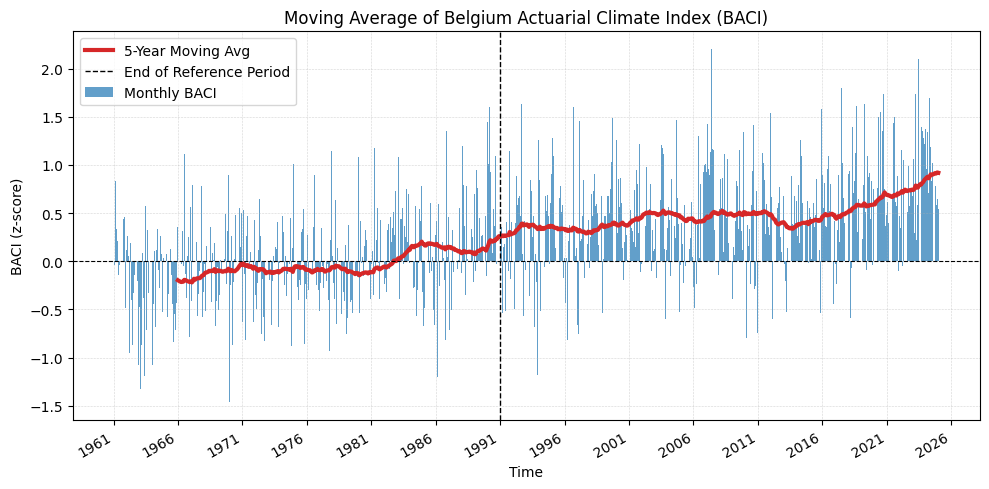

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import datetime

# ── 1) Load BACI composite ───────────────────────────────────────────────
ds = xr.open_dataset("ACI-Python/data/composites/BACI_composite.nc")
baci_da = ds["BACI"]

# ── 2) Ensure 1-D monthly BACI series (collapse extra dims if any) ────────
spatial_dims = [d for d in baci_da.dims if d != "time"]
monthly_baci = baci_da.mean(dim=spatial_dims) if spatial_dims else baci_da
if "step" in monthly_baci.dims:
    monthly_baci = monthly_baci.mean(dim="step")

# Keep 1961–end and convert to pandas Series
baci_series = (
    monthly_baci
    .sel(time=slice("1961-01-01", None))
    .to_series()
    .dropna()
)

# ── 3) Right-aligned 60-month rolling mean (full window only) ─────────────
rolling_60 = (
    baci_series
    .rolling(window=60, center=False, min_periods=60)
    .mean()
    .dropna()
)

# ── 4) Plot bars + moving average ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# a) Monthly BACI bars
ax.bar(
    baci_series.index,
    baci_series.values,
    width=25,           # in days
    color="tab:blue",
    alpha=0.7,
    label="Monthly BACI"
)

# b) 5-year moving average line
ax.plot(
    rolling_60.index,
    rolling_60.values,
    color="tab:red",
    linewidth=3,
    label="5-Year Moving Avg"
)

# ── 5) Vertical line at end of reference period ───────────────────────────
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(
    ref_end,
    color="black",
    linestyle="--",
    linewidth=1,
    label="End of Reference Period"
)

# ── 6) Cosmetics ──────────────────────────────────────────────────────────
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Moving Average of Belgium Actuarial Climate Index (BACI)")
ax.set_xlabel("Time")
ax.set_ylabel("BACI (z-score)")
ax.grid(True, linestyle=":", linewidth=0.4)
ax.legend()

# ── 7) Custom 5-year x-axis ticks ─────────────────────────────────────────
years = list(range(1961, datetime.datetime.now().year + 2, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()

# ── 8) Save figure ────────────────────────────────────────────────────────
fig.savefig("BACI_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("✅ Plot saved as BACI_bars_and_moving_avg_fullwindow.png")

plt.show()


✅ Plot saved as BACIcomponents_bars_and_moving_avg_fullwindow.png


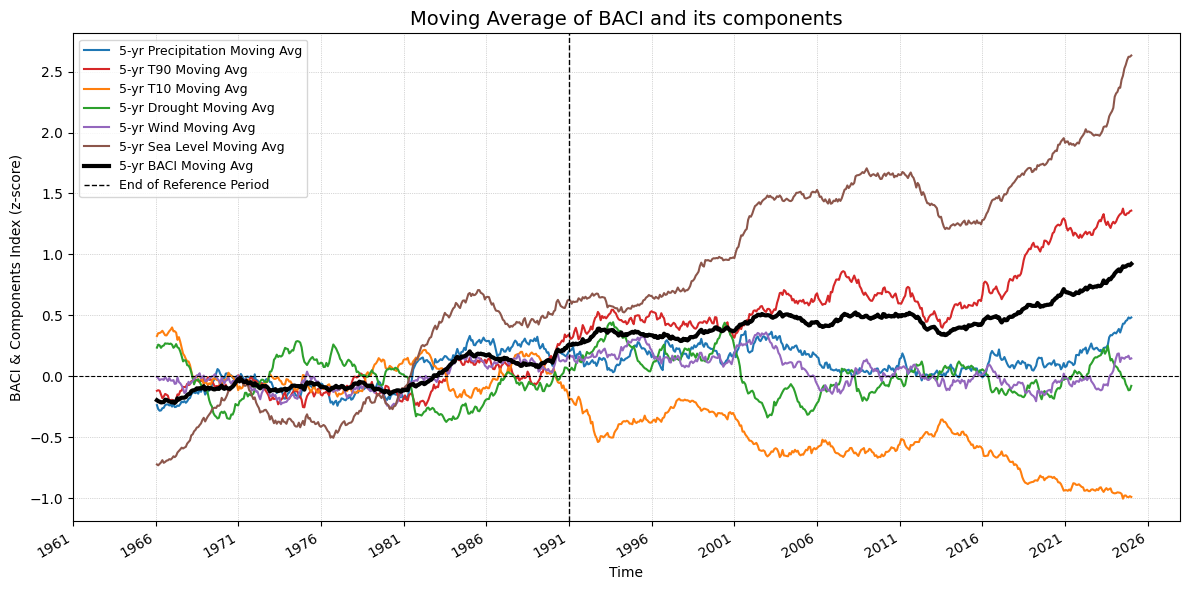

In [15]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

def load_index_series(name, path):
    """
    Load a NetCDF (with one or multiple vars), collapse non-time dims,
    and return a pandas Series indexed at month-end from Jan 1961 onward.
    """
    ds = xr.open_dataset(path)
    # pick the single var, or stack & average if multi-var (e.g. sea level)
    if len(ds.data_vars) == 1:
        da = next(iter(ds.data_vars.values()))
    else:
        da = ds.to_array().mean(dim="variable")
    # collapse any other dims (step, spatial, etc.)
    other_dims = [d for d in da.dims if d != "time"]
    if other_dims:
        da = da.mean(dim=other_dims, skipna=True)
    # slice from 1961-01-01, convert to Series, drop NaNs
    ser = da.sel(time=slice("1961-01-01", None)).to_series().dropna()
    # shift index to month-end
    ser.index = pd.to_datetime(ser.index) + pd.offsets.MonthEnd(1)
    return ser

# ── 1. Define paths ─────────────────────────────────────────────────────────
dir_path = "ACI-Python/data/composites"
# six components follow the "*_index.nc" naming
components = ["precipitation","t90","t10","drought","wind","sealevel"]
# BACI is stored as "BACI_composite.nc"
paths = {c: f"{dir_path}/{c}_index.nc" for c in components}
paths["BACI"] = f"{dir_path}/BACI_composite.nc"

# ── 2. Load all series ─────────────────────────────────────────────────────
series = {name: load_index_series(name, paths[name]) for name in components + ["BACI"]}

# ── 3. Compute 60-month trailing (right-aligned) rolling means ────────────
rolling = {}
for name, s in series.items():
    roll = s.rolling(window=60, center=False, min_periods=60).mean()
    rolling[name] = roll.dropna()

# Restrict start to first full window (Jan 1966)
for name in rolling:
    rolling[name] = rolling[name].loc["1966-01-01":"2024-12-31"]

# ── 4. Plot everything ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
colors = {
    "precipitation":"tab:blue",
    "t90":"tab:red",
    "t10":"tab:orange",
    "drought":"tab:green",
    "wind":"tab:purple",
    "sealevel":"tab:brown",
    "BACI":"black"
}
labels = {
    "precipitation":"Precipitation",
    "t90":"T90",
    "t10":"T10",
    "drought":"Drought",
    "wind":"Wind",
    "sealevel":"Sea Level",
    "BACI":"BACI"
}

for name, ser in rolling.items():
    lw = 3 if name == "BACI" else 1.5
    ax.plot(
        ser.index,
        ser.values,
        color=colors[name],
        linewidth=lw,
        label=f"5-yr {labels[name]} Moving Avg"
    )

# Reference‐period divider & zero line
ref_end = pd.to_datetime("1990-12-31")
ax.axvline(ref_end, color="black", linestyle="--", linewidth=1, label="End of Reference Period")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)

# Cosmetics & ticks
ax.set_title("Moving Average of BACI and its components", fontsize=14)
ax.set_xlabel("Time")
ax.set_ylabel("BACI & Components Index (z-score)")
ax.grid(True, linestyle=":", linewidth=0.5)

years = list(range(1961, 2027, 5))
xticks = [datetime.datetime(y, 1, 1) for y in years]
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()

# ── Save & show ───────────────────────────────────────────────────────────
fig.savefig("BACIcomponents_bars_and_moving_avg_fullwindow.png", dpi=300, bbox_inches="tight")
print("✅ Plot saved as BACIcomponents_bars_and_moving_avg_fullwindow.png")

plt.show()


🔗 Correlation matrix between composites:
               precipitation    t90    t10  drought   wind  sealevel   BACI
precipitation          1.000 -0.048 -0.051   -0.387  0.377     0.345  0.433
t90                   -0.048  1.000 -0.730    0.139  0.007     0.327  0.698
t10                   -0.051 -0.730  1.000    0.030 -0.061    -0.403 -0.707
drought               -0.387  0.139  0.030    1.000 -0.277    -0.270  0.044
wind                   0.377  0.007 -0.061   -0.277  1.000     0.345  0.478
sealevel               0.345  0.327 -0.403   -0.270  0.345     1.000  0.726
BACI                   0.433  0.698 -0.707    0.044  0.478     0.726  1.000
✅ Plot saved as composites_correlation_heatmap.png


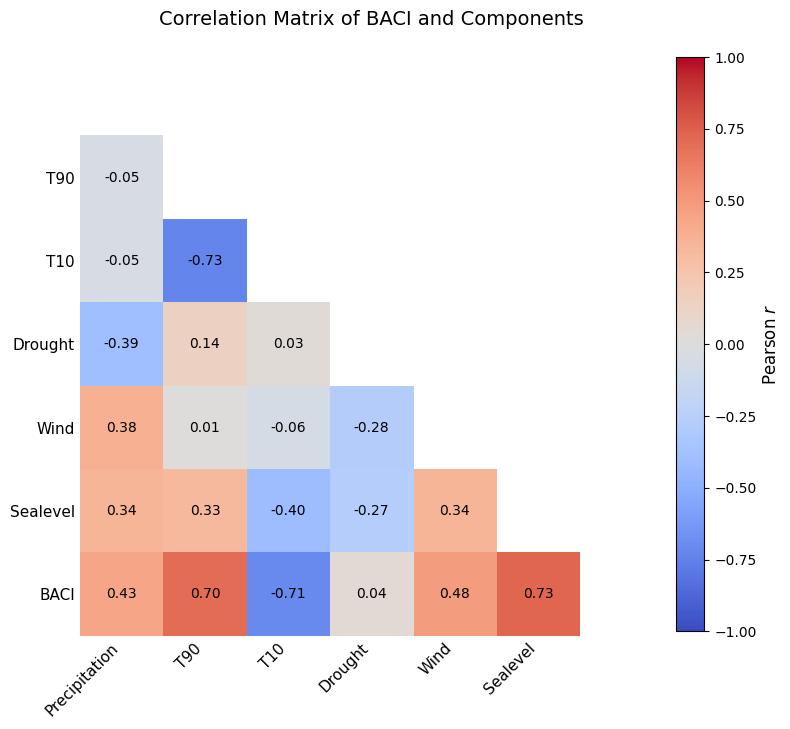


⏱️ Total run time: 0.27 seconds


In [16]:
import os    ### You MUST MODIFY the plot saving path! ###
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Start timer ───────────────────────────────────────────────────────────
t0 = time.perf_counter()

# ── Config ────────────────────────────────────────────────────────────────
dir_path   = "ACI-Python/data/composites"
components = ["precipitation", "t90", "t10", "drought", "wind", "sealevel", "BACI"]

paths = {c: os.path.join(dir_path, f"{c}_index.nc") for c in components if c != "BACI"}
paths["BACI"] = os.path.join(dir_path, "BACI_composite.nc")

# Fixed monthly grid (1961‑01 → 2024‑12, month‑end timestamps)
full_idx = pd.period_range("1961-01", "2024-12", freq="M").to_timestamp("M")

# ── Helpers ───────────────────────────────────────────────────────────────
def open_var_robust(path: str, preferred: str | None = None) -> xr.DataArray:
    """
    Try to open a NetCDF as a DataArray; fall back to Dataset and pick a variable.
    If 'preferred' is given and present, use it.
    """
    try:
        return xr.open_dataarray(path)
    except Exception:
        ds = xr.open_dataset(path)
        if preferred and preferred in ds.data_vars:
            return ds[preferred]
        if len(ds.data_vars) == 0:
            raise ValueError(f"No data variables in {path}")
        return next(iter(ds.data_vars.values()))

def da_to_series_aligned(da: xr.DataArray) -> pd.Series:
    """Collapse non-time dims → mean (skipna), normalize to month-end (no shift), align to full grid."""
    time_dim = "time" if "time" in da.dims else da.dims[0]
    other_dims = [d for d in da.dims if d != time_dim]
    if other_dims:
        da = da.mean(dim=other_dims, skipna=True)
    s = da.to_series()
    # ✅ month-end without advancing to next month
    s.index = pd.to_datetime(s.index).to_period("M").to_timestamp("M")
    return s.reindex(full_idx)

# ── Load all series (robust) ──────────────────────────────────────────────
series = {}
for c in components:
    path = paths[c]
    if c == "sealevel":
        ds = xr.open_dataset(path)
        da = ds.to_array().mean(dim="variable", skipna=True)  # average stations
    elif c == "BACI":
        da = open_var_robust(path, preferred="BACI")
    else:
        da = open_var_robust(path, preferred=c)
    series[c] = da_to_series_aligned(da).astype("float64")

# ── Merge into a single DataFrame and compute correlation ─────────────────
merged = pd.DataFrame(series, index=full_idx)
corr = merged.dropna().corr()

print("🔗 Correlation matrix between composites:")
print(corr.round(3).to_string())

# ── Prepare labels (rename ACI→BACI already done) ─────────────────────────
labels = corr.columns.tolist()
display_labels = [lbl if lbl == "BACI" else lbl.capitalize() for lbl in labels]

N        = len(labels)
prec_idx = labels.index("precipitation")
baci_idx = labels.index("BACI")

# ── Build mask: diagonal+upper triangle, plus full precipitation row & BACI column ──
mask = np.triu(np.ones((N, N), dtype=bool), k=0)
mask[prec_idx, :] = True
mask[:, baci_idx] = True

# ── Colormap: diverging –1→+1, masked=white ───────────────────────────────
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad("white")
norm = mcolors.Normalize(vmin=-1, vmax=1)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
masked_data = np.ma.masked_where(mask, corr.values)
im = ax.imshow(masked_data, cmap=cmap, norm=norm, aspect="equal", interpolation="none")

# Annotate only the strictly lower-triangle cells (i > j) that remain
for i in range(N):
    for j in range(i):
        if not mask[i, j]:
            ax.text(j, i, f"{corr.iat[i, j]:.2f}", ha="center", va="center", fontsize=10, color="black")

# Ticks & Tick Labels (blank precipitation row label and BACI column label)
ax.set_xticks(np.arange(N)); ax.set_yticks(np.arange(N))
xtick_labels = ["" if idx == baci_idx else display_labels[idx] for idx in range(N)]
ytick_labels = ["" if idx == prec_idx else display_labels[idx] for idx in range(N)]
ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(ytick_labels, fontsize=11)

# Clean look
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label("Pearson $r$", fontsize=12)

ax.set_title("Correlation Matrix of BACI and Components", fontsize=14, pad=20)
plt.tight_layout()

# ── Save & show ───────────────────────────────────────────────────────────
fig.savefig("BACI_composites_correlation_heatmap.png", dpi=300, bbox_inches="tight")
print("✅ Plot saved as composites_correlation_heatmap.png")

plt.show()

# ── Timer ─────────────────────────────────────────────────────────────────
t1 = time.perf_counter()
print(f"\n⏱️ Total run time: {t1 - t0:.2f} seconds")


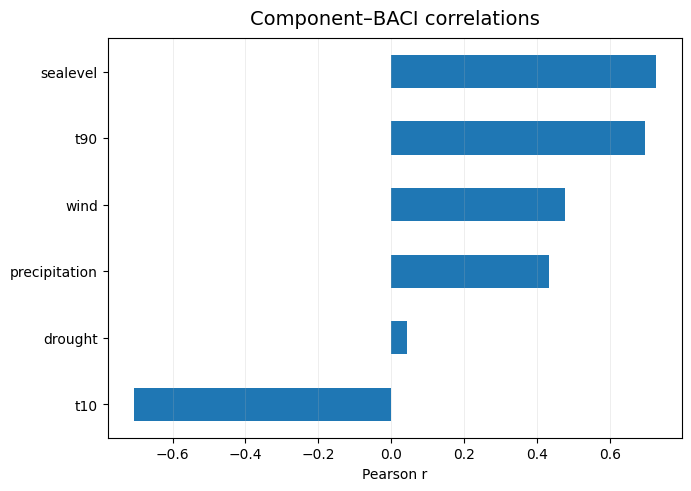

🖼️ Saved: ACI-Python/data/composites/BACI_component_correlations.png


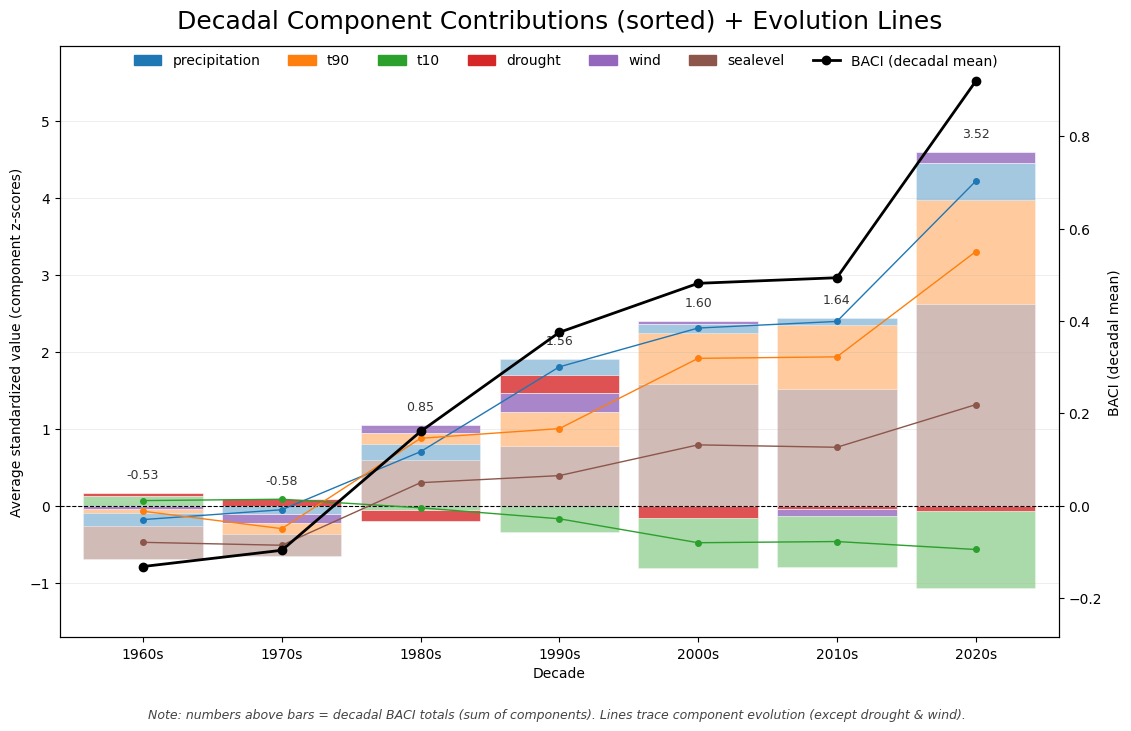

🖼️ Saved: ACI-Python/data/composites/BACI_decadal_components_lines.png
✅ Finished. Total time: 0.33 s


In [13]:
# baci_component_plots_timeline_sorted_big_png_only.py
import os
import time
from typing import Dict
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

t0 = time.perf_counter()

# ── Paths ─────────────────────────────────────────────────────────────────
dir_path = "ACI-Python/data/composites"
paths: Dict[str, str] = {
    "precipitation": os.path.join(dir_path, "precipitation_index.nc"),
    "t90":           os.path.join(dir_path, "t90_index.nc"),
    "t10":           os.path.join(dir_path, "t10_index.nc"),
    "drought":       os.path.join(dir_path, "drought_index.nc"),
    "wind":          os.path.join(dir_path, "wind_index.nc"),
    "sealevel":      os.path.join(dir_path, "sealevel_index.nc"),
}
baci_path = os.path.join(dir_path, "BACI_composite.nc")

# ── Fixed monthly grid ────────────────────────────────────────────────────
full_idx = pd.period_range("1961-01", "2024-12", freq="M").to_timestamp("M")

# ── Helpers ───────────────────────────────────────────────────────────────
def _collapse_to_series(da: xr.DataArray, name: str) -> pd.Series:
    """Collapse non-time dims → mean (skipna), align to full_idx."""
    time_dim = "time" if "time" in da.dims else da.dims[0]
    other_dims = [d for d in da.dims if d != time_dim]
    if other_dims:
        da = da.mean(dim=other_dims, skipna=True)
    s = da.to_series()
    s.index = pd.to_datetime(s.index).to_period("M").to_timestamp("M")
    return s.reindex(full_idx).rename(name)

def load_component_series(name: str, path: str) -> pd.Series:
    ds = xr.open_dataset(path)
    da = ds.to_array().mean(dim="variable", skipna=True)  # robust for 1+ vars
    if "step" in da.dims:
        da = da.mean(dim="step")
    if "time" in da.coords:
        da = da.sel(time=slice("1961-01-01", None))
    return _collapse_to_series(da, name)

# ── Load components & BACI ────────────────────────────────────────────────
components = ["precipitation","t90","t10","drought","wind","sealevel"]
comp = {k: load_component_series(k, p) for k, p in paths.items()}
df = pd.DataFrame(comp, index=full_idx)

baci_ds = xr.open_dataset(baci_path)
baci = baci_ds["BACI"].to_series()
baci.index = pd.to_datetime(baci.index).to_period("M").to_timestamp("M")
df["BACI"] = baci.reindex(full_idx)

# Sanity: stop if there are gaps
nan_counts = df.isna().sum()
if nan_counts.sum():
    raise RuntimeError(f"Unexpected NaNs present, cannot plot:\n{nan_counts}")

# ── Figure 1: Component–BACI correlations (PNG only) ─────────────────────
corr = df.corr()["BACI"].drop("BACI").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6.8, 4.8), constrained_layout=True)
corr.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Component–BACI correlations", fontsize=14, pad=10)
ax.set_xlabel("Pearson r")
ax.grid(axis="x", alpha=0.25, linewidth=0.6)
out_corr_png = os.path.join(dir_path, "BACI_component_correlations.png")
fig.savefig(out_corr_png, dpi=300, bbox_inches="tight")
plt.show()
print(f"🖼️ Saved: {out_corr_png}")

# ── Figure 2: Timeline stacks (sorted per decade) + BACI twin y-axis ─────
# ── Colors ───────────────────────────────────────────────────────────────
color_map = {
    "precipitation": "#1f77b4",
    "t90":           "#ff7f0e",
    "t10":           "#2ca02c",
    "drought":       "#d62728",
    "wind":          "#9467bd",
    "sealevel":      "#8c564b",
}

# ── Decadal means ────────────────────────────────────────────────────────
dec_comp_means = df.assign(decade=df.index.year // 10 * 10).groupby("decade")[components].mean()
dec_baci = df.assign(decade=df.index.year // 10 * 10).groupby("decade")["BACI"].mean()

decades = dec_comp_means.index.to_list()
x = np.arange(len(decades))
bar_width = 0.86

# ── Figure ───────────────────────────────────────────────────────────────
fig_width = max(11, 1.6 * len(decades))
fig_height = 7.2
fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)

pos_tops, neg_bottoms = [], []
centers = {c: [] for c in components}
xpos    = {c: [] for c in components}

# Bars (alpha=0.40, except drought/wind solid)
for i, decade in enumerate(decades):
    row = dec_comp_means.loc[decade].sort_values(ascending=False)
    base_pos, base_neg = 0.0, 0.0
    for comp_name, val in row.items():
        c = color_map[comp_name]
        bar_alpha = 0.80 if comp_name in ["drought","wind"] else 0.40
        if val >= 0:
            ax.bar(x[i], val, bottom=base_pos, color=c, alpha=bar_alpha,
                   width=bar_width, edgecolor="white", linewidth=0.5, zorder=1)
            centers[comp_name].append(base_pos + val/2.0); xpos[comp_name].append(x[i])
            base_pos += val
        else:
            ax.bar(x[i], val, bottom=base_neg, color=c, alpha=bar_alpha,
                   width=bar_width, edgecolor="white", linewidth=0.5, zorder=1)
            centers[comp_name].append(base_neg + val/2.0); xpos[comp_name].append(x[i])
            base_neg += val
    pos_tops.append(base_pos); neg_bottoms.append(base_neg)

# Lines (dashed) — skip drought & wind
for comp_name in components:
    if comp_name in ["drought", "wind"]:
        continue
    ax.plot(
        xpos[comp_name], centers[comp_name],
        color=color_map[comp_name], linewidth=1.0, alpha=1.0,
        linestyle="-", marker="o", markersize=4, zorder=3
    )

# Axis styling
ax.set_xticks(x)
ax.set_xticklabels([f"{d}s" for d in decades])
ax.set_xlim(-0.6, len(decades) - 0.4)
ax.set_title(
    "Decadal Component Contributions (sorted) + Evolution Lines",
    fontsize=18, pad=13
)
ax.set_ylabel("Average standardized value (component z-scores)")
ax.set_xlabel("Decade")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.grid(axis="y", alpha=0.25, linewidth=0.6)

# Padding
ymin = min(0, min(neg_bottoms)) * 1.6
ymax = max(0, max(pos_tops)) * 1.3
ax.set_ylim(ymin, ymax)

# BACI twin axis
ax2 = ax.twinx()
ax2.set_ylabel("BACI (decadal mean)")
ax2.set_ylim(ymin/6.0, ymax/6.0)
ax2.plot(x, dec_baci.values, color="black", marker="o", linewidth=2.0,
         label="BACI (decadal mean)", zorder=4)

# Totals above bars
for i,(top,bot) in enumerate(zip(pos_tops, neg_bottoms)):
    tot = top + bot
    if abs(tot) >= 0.15:
        ax.text(x[i], top + 0.02*(ymax - ymin), f"{tot:.2f}",
                ha="center", va="bottom", fontsize=9, color="#333333", zorder=5)

# Legend inside
handles = [plt.matplotlib.patches.Patch(color=color_map[k], label=k) for k in components]
handles.append(plt.Line2D([0],[0], color="black", lw=2.0, marker="o", label="BACI (decadal mean)"))
fig.legend(handles=handles, loc="upper center", ncol=min(7, len(handles)),
           frameon=False, bbox_to_anchor=(0.5, 0.95))

# Explanatory note
ax.text(
    0.5, -0.12,
    "Note: numbers above bars = decadal BACI totals (sum of components). "
    "Lines trace component evolution (except drought & wind). ",
    ha="center", va="top", transform=ax.transAxes,
    fontsize=9, color="#444", style="italic"
)

# Save PNG only
out_png = os.path.join(dir_path, "BACI_decadal_components_lines.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"🖼️ Saved: {out_png}")
print(f"✅ Finished. Total time: {time.perf_counter() - t0:.2f} s")
